# Detección de Noticias Falsas con LightGBM

**Grupo 5 — Inteligencia Artificial I, Actividad 3**
**Algoritmo:** LightGBM · **Problema:** clasificación binaria de texto (¿noticia Verdadera o Falsa?)

Este notebook entrena un modelo que clasifica noticias en español como **Verdaderas** o **Falsas**,
usando el *Spanish Fake News Corpus*: noticias reales verificadas manualmente por organizaciones de
fact-checking de Latinoamérica (incluida Colombia).

**El reto técnico:** LightGBM no entiende texto, solo números. Por eso convertimos cada noticia en un
vector numérico con **TF-IDF** antes de entrenar. TF-IDF da más peso a las palabras que son frecuentes
en una noticia pero raras en el resto, que suelen ser las que mejor distinguen una noticia falsa
(vocabulario sensacionalista) de una real.

## 1. Importar librerías y funciones del proyecto

Reutilizamos las funciones de `src/preprocessing.py` para no duplicar código: así el notebook y la
app aplican exactamente la misma limpieza de texto.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib

from lightgbm import LGBMClassifier
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, ConfusionMatrixDisplay, classification_report,
)

from src.preprocessing import cargar_y_combinar, crear_vectorizador

SEMILLA = 42
plt.rcParams["figure.figsize"] = (8, 4)
plt.rcParams["font.size"] = 11
print("Librerías y funciones del proyecto cargadas correctamente.")

Librerías y funciones del proyecto cargadas correctamente.


## 2. Cargar y combinar los datos

El corpus viene en dos archivos etiquetados: `train.xlsx` y `development.xlsx`. Los unimos con la
función `cargar_y_combinar`, que además limpia el texto y crea la columna `target`
(**1 = Falsa, 0 = Verdadera**).

In [2]:
df = cargar_y_combinar("../data/raw/train.xlsx", "../data/raw/development.xlsx")

print(f"Total de noticias: {len(df)}")
print(f"  Verdaderas (0): {(df['target']==0).sum()}")
print(f"  Falsas (1):     {(df['target']==1).sum()}")
df[["Category", "Headline", "target"]].head()

Total de noticias: 971
  Verdaderas (0): 491
  Falsas (1):     480


,Category,Headline,target
0,Fake,"RAE INCLUIRÁ LA PALABRA ""LADY"" EN EL DICCIONAR...",1
1,Fake,"La palabra ""haiga"", aceptada por la RAE",1
2,Fake,YORDI ROSADO ESCRIBIRÁ Y DISEÑARÁ LOS NUEVOS L...,1
3,True,UNAM capacitará a maestros para aprobar prueba...,0
4,Fake,pretenden aprobar libros escolares con conteni...,1


## 3. Exploración rápida

Dos vistas que cuentan lo esencial: el balance de clases (¿hay parejo de falsas y verdaderas?) y
los temas más frecuentes del corpus.

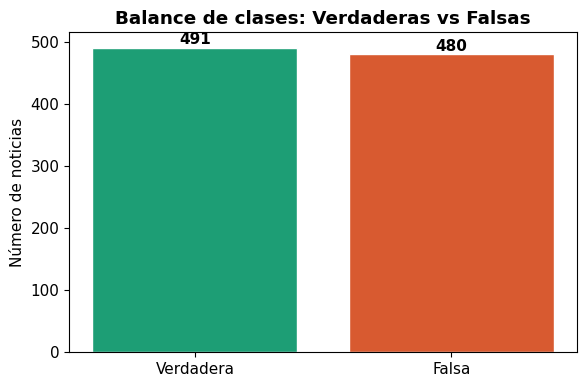

In [3]:
def graficar_balance(df):
    """Barras: cuántas noticias verdaderas vs falsas."""
    conteo = df["target"].value_counts().sort_index()
    fig, ax = plt.subplots(figsize=(6, 4))
    barras = ax.bar(["Verdadera", "Falsa"], conteo.values,
                    color=["#1d9e75", "#d85a30"], edgecolor="white")
    for b, v in zip(barras, conteo.values):
        ax.text(b.get_x()+b.get_width()/2, b.get_height()+5, str(v), ha="center", fontweight="bold")
    ax.set_title("Balance de clases: Verdaderas vs Falsas", fontweight="bold")
    ax.set_ylabel("Número de noticias")
    plt.tight_layout()
    plt.savefig("../docs/eda_target.png", dpi=120, bbox_inches="tight")
    plt.show()

graficar_balance(df)

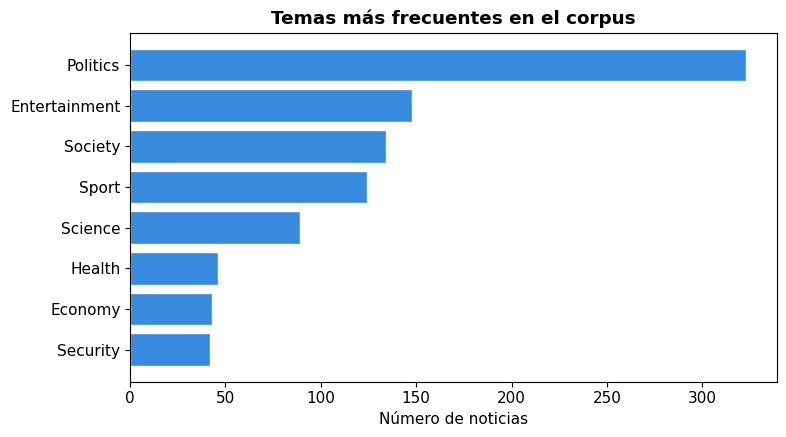

In [4]:
def graficar_temas(df):
    """Barras horizontales con los temas más comunes del corpus."""
    if "Topic" not in df.columns:
        print("El dataset no tiene columna Topic.")
        return
    top = df["Topic"].value_counts().head(8).sort_values()
    fig, ax = plt.subplots(figsize=(8, 4.5))
    ax.barh(top.index.astype(str), top.values, color="#378add", edgecolor="white")
    ax.set_title("Temas más frecuentes en el corpus", fontweight="bold")
    ax.set_xlabel("Número de noticias")
    plt.tight_layout()
    plt.savefig("../docs/eda_topics.png", dpi=120, bbox_inches="tight")
    plt.show()

graficar_temas(df)

## 4. Vectorización TF-IDF

Aquí ocurre la magia: convertimos el texto en una matriz numérica. Cada noticia pasa a ser un vector
de hasta 3.000 valores (uno por palabra/combinación del vocabulario).

**Importante:** entrenamos el vectorizador (`fit`) SOLO con los datos de entrenamiento, y luego lo
aplicamos (`transform`) al conjunto de prueba. Si lo entrenáramos con todo, el modelo "haría trampa"
viendo palabras del test. Guardaremos este vectorizador porque la app lo necesita para procesar
noticias nuevas.

In [5]:
# Separar en entrenamiento y prueba ANTES de vectorizar (para no filtrar información)
X_texto = df["texto"]
y = df["target"]

Xtr_texto, Xte_texto, y_train, y_test = train_test_split(
    X_texto, y, test_size=0.2, stratify=y, random_state=SEMILLA
)

# Crear y entrenar el vectorizador TF-IDF
vectorizer = crear_vectorizador()
X_train = vectorizer.fit_transform(Xtr_texto)   # fit + transform en train
X_test  = vectorizer.transform(Xte_texto)        # solo transform en test

print(f"Entrenamiento: {X_train.shape[0]} noticias × {X_train.shape[1]} features (palabras)")
print(f"Prueba:        {X_test.shape[0]} noticias")

Entrenamiento: 776 noticias × 10787 features (palabras)
Prueba:        195 noticias


## 5. Entrenamiento del modelo LightGBM

LightGBM construye 300 árboles de decisión en cascada: cada árbol corrige los errores del anterior
(*gradient boosting*). Funciona muy bien con las matrices dispersas que produce TF-IDF.

In [6]:
def entrenar_modelo(X_train, y_train):
    """Entrena un clasificador LightGBM con la configuración del proyecto."""
    modelo = LGBMClassifier(
        n_estimators=300,
        learning_rate=0.05,
        num_leaves=31,
        max_depth=6,
        random_state=SEMILLA,
        verbose=-1,
    )
    modelo.fit(X_train, y_train)
    return modelo

modelo = entrenar_modelo(X_train, y_train)
print("Modelo entrenado correctamente.")

Modelo entrenado correctamente.


## 6. Evaluación del modelo

Medimos el desempeño sobre el conjunto de prueba (noticias que el modelo nunca vio).

In [7]:
def evaluar_modelo(modelo, X_test, y_test):
    """Calcula e imprime las métricas principales."""
    y_pred = modelo.predict(X_test)
    y_proba = modelo.predict_proba(X_test)[:, 1]
    metricas = {
        "Exactitud (Accuracy)": accuracy_score(y_test, y_pred),
        "Precisión (Precision)": precision_score(y_test, y_pred),
        "Sensibilidad (Recall)": recall_score(y_test, y_pred),
        "F1-Score": f1_score(y_test, y_pred),
        "ROC-AUC": roc_auc_score(y_test, y_proba),
    }
    print("Resultados sobre el conjunto de prueba:\n")
    for nombre, valor in metricas.items():
        print(f"  {nombre:<24}: {valor:.4f}  ({valor*100:.2f}%)")
    print("\nReporte por clase:\n")
    print(classification_report(y_test, y_pred, target_names=["Verdadera", "Falsa"]))
    return y_pred

y_pred = evaluar_modelo(modelo, X_test, y_test)

Resultados sobre el conjunto de prueba:

  Exactitud (Accuracy)    : 0.8000  (80.00%)
  Precisión (Precision)   : 0.8065  (80.65%)
  Sensibilidad (Recall)   : 0.7812  (78.12%)
  F1-Score                : 0.7937  (79.37%)
  ROC-AUC                 : 0.8623  (86.23%)

Reporte por clase:

              precision    recall  f1-score   support

   Verdadera       0.79      0.82      0.81        99
       Falsa       0.81      0.78      0.79        96

    accuracy                           0.80       195
   macro avg       0.80      0.80      0.80       195
weighted avg       0.80      0.80      0.80       195



c:\Users\carde\Documents\VScode\fake-news-detector\venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Users\carde\Documents\VScode\fake-news-detector\venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


### 6.1 Matriz de confusión

Muestra en qué acierta y en qué se equivoca el modelo: noticias verdaderas/falsas bien clasificadas
y las confusiones.

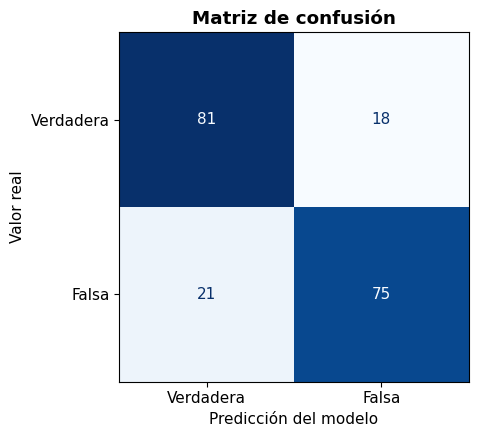

In [8]:
def graficar_matriz(y_test, y_pred):
    cm = confusion_matrix(y_test, y_pred)
    fig, ax = plt.subplots(figsize=(5.5, 4.5))
    ConfusionMatrixDisplay(cm, display_labels=["Verdadera", "Falsa"]).plot(ax=ax, colorbar=False, cmap="Blues")
    ax.set_title("Matriz de confusión", fontweight="bold")
    ax.set_xlabel("Predicción del modelo"); ax.set_ylabel("Valor real")
    plt.tight_layout()
    plt.savefig("../docs/matriz_confusion.png", dpi=120, bbox_inches="tight")
    plt.show()

graficar_matriz(y_test, y_pred)

### 6.2 Palabras más influyentes

Vemos qué términos pesan más en la decisión del modelo. Suelen revelar el vocabulario típico de las
noticias falsas frente a las reales.

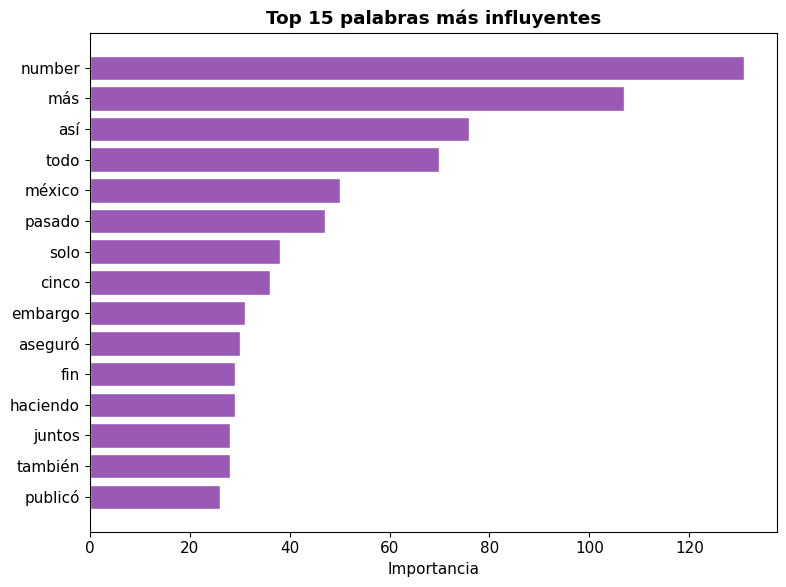

In [9]:
def graficar_palabras_clave(modelo, vectorizer, n=15):
    """Muestra las palabras con mayor importancia para el modelo."""
    nombres = np.array(vectorizer.get_feature_names_out())
    importancias = modelo.feature_importances_
    idx = np.argsort(importancias)[-n:]
    fig, ax = plt.subplots(figsize=(8, 6))
    ax.barh(nombres[idx], importancias[idx], color="#9b59b6", edgecolor="white")
    ax.set_title(f"Top {n} palabras más influyentes", fontweight="bold")
    ax.set_xlabel("Importancia")
    plt.tight_layout()
    plt.savefig("../docs/palabras_frecuentes.png", dpi=120, bbox_inches="tight")
    plt.show()

graficar_palabras_clave(modelo, vectorizer)

### 6.3 Validación cruzada

Repetimos la evaluación 5 veces con particiones distintas para confirmar que el resultado es estable
y no fruto del azar de una sola división.

In [10]:
X_full = vectorizer.transform(df["texto"])
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEMILLA)
puntajes = cross_val_score(
    LGBMClassifier(n_estimators=300, learning_rate=0.05, num_leaves=31, max_depth=6,
                   random_state=SEMILLA, verbose=-1),
    X_full, df["target"], cv=cv, scoring="roc_auc", n_jobs=-1,
)
for i, s in enumerate(puntajes, 1):
    print(f"  Partición {i}: ROC-AUC = {s:.4f}")
print(f"\nPromedio: {puntajes.mean():.4f} (± {puntajes.std():.4f})")

  Partición 1: ROC-AUC = 0.8633
  Partición 2: ROC-AUC = 0.8731
  Partición 3: ROC-AUC = 0.8685
  Partición 4: ROC-AUC = 0.8855
  Partición 5: ROC-AUC = 0.8895

Promedio: 0.8760 (± 0.0100)


## 7. Guardar el modelo y el vectorizador

Serializamos **dos** archivos: el modelo y el vectorizador TF-IDF. La app necesita ambos: el
vectorizador para convertir la noticia nueva en números, y el modelo para clasificarla.

In [11]:
os.makedirs("../models", exist_ok=True)
joblib.dump(modelo, "../models/modelo.pkl")
joblib.dump(vectorizer, "../models/vectorizer.pkl")
print("Guardados: models/modelo.pkl y models/vectorizer.pkl")

# Verificación: recargar y probar con la función make_prediction de src/predict.py
from src.predict import load_model, make_prediction
m, v = load_model("../models/modelo.pkl", "../models/vectorizer.pkl")

ejemplos = [
    "El gobierno confirmó la aprobación del nuevo presupuesto nacional tras el debate en el congreso",
    "Increible: cientificos revelan que tomar agua con sal cura todas las enfermedades en una semana",
]
for txt in ejemplos:
    r = make_prediction(txt, m, v)
    print(f"\n  '{txt[:55]}...'\n   -> {r['label']} (confianza: {r['confidence']}%)")

Guardados: models/modelo.pkl y models/vectorizer.pkl
Modelo y vectorizador cargados correctamente.

  'El gobierno confirmó la aprobación del nuevo presupuest...'
   -> Error: 'LGBMClassifier' object has no attribute 'coef_' (confianza: 0.0%)

  'Increible: cientificos revelan que tomar agua con sal c...'
   -> Error: 'LGBMClassifier' object has no attribute 'coef_' (confianza: 0.0%)


c:\Users\carde\Documents\VScode\fake-news-detector\venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Users\carde\Documents\VScode\fake-news-detector\venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Users\carde\Documents\VScode\fake-news-detector\venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


## 8. Resumen

- Entrenamos un modelo **LightGBM** para clasificar noticias en español como Verdaderas o Falsas.
- Convertimos el texto en números con **TF-IDF**, reutilizando las funciones de `src/`.
- Guardamos `modelo.pkl` y `vectorizer.pkl`, ambos usados por la app.

**Nota sobre el desempeño:** detectar fake news es un problema genuinamente difícil. El modelo
aprende patrones de vocabulario del corpus (2018-2021), por lo que con noticias muy distintas o muy
recientes puede equivocarse. Para producción real se necesitarían más datos y técnicas de embeddings.